# Image and Video Processing - Lab 2: Enhancement and Restoration

In this lab, you will learn about noise, denoising, histogram based enhancement and inpainting in Python.

**In order to complete the Lab, you need to finish all required tasks in the lab session and have one of the teacher to check your result.**

Import the required libraries and define a helper function to display images. Load the image using OpenCV, convert it to greyscale format, and display the greyscale.

<class 'numpy.ndarray'>


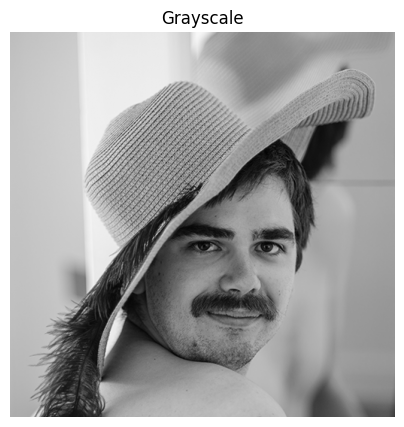

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append(os.path.join(os.getcwd(),'..', 'ivp', "lib", "python3.12", "site-packages"))
import cv2

def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


img = cv2.imread('EthicalLena_512.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(type(img))

show_images([gray], ["Grayscale"], cmap='gray')

## 1. Add Noise

### 1.1 Gaussian Noise


Write a function to add Gaussian noise to the image using a normal distribution with mean 0 and standard deviation 25. Display the original and noisy images side by side.
*Hint:** Use `np.random.normal`, `np.clip`, and type conversion.

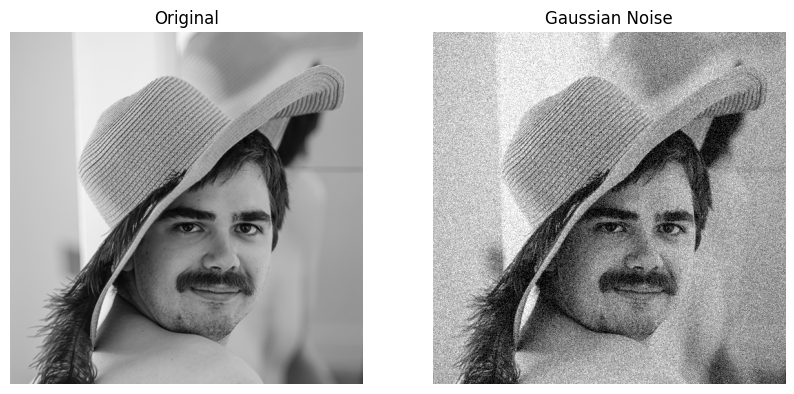

In [7]:
def add_gaussian_noise(image, mean=0, sigma=50):
    noise = np.random.normal(loc=mean, scale=sigma, size=image.shape)
    new_image = image + noise
    new_image = np.clip(new_image, 0, 255)
    return new_image

gaussian_noisy = add_gaussian_noise(gray, mean=0, sigma = 25)

show_images(
    [gray, gaussian_noisy],
    ["Original", "Gaussian Noise"]
)

### 1.2 Salt & Pepper Noise

Write a function to add salt and pepper noise to the greyscale image. 2.5% of the pixels should have salf noise and 2.5% should have pepper noise.

Display the original and noisy images side by side.

**Hint:** Use the `np.random` function to choose location of the noise.

In [10]:
print(len(img))
print(img.shape)

512
(512, 512, 3)


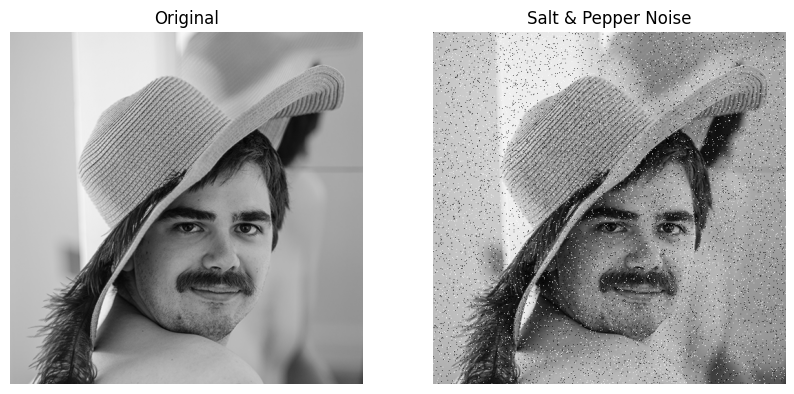

In [14]:
def add_salt_pepper_noise(img, salt_prob=0.025, pepper_prob=0.025):
    x,y = img.shape[:2]
    n_salt = int(x*y*salt_prob)
    n_pepper = int(x*y*pepper_prob)
    x_rand_salt = np.random.choice(x, n_salt)
    x_rand_pepper = np.random.choice(x, n_pepper)
    y_rand_salt = np.random.choice(y, n_salt)
    y_rand_pepper = np.random.choice(y, n_pepper)
    new_img = img.copy()
    for i in range(n_salt):
        r = x_rand_salt[i]
        c = y_rand_salt[i]
        new_img[r][c] = 255
    for i in range(n_pepper):
        r = x_rand_pepper[i]
        c = y_rand_pepper[i]
        new_img[r][c] = 0
    return new_img

sp_noisy = add_salt_pepper_noise(gray)

show_images(
    [gray, sp_noisy],
    ["Original", "Salt & Pepper Noise"])

## 2. Denoising

### 2.1 Mean Filter

Apply a mean filter with kernel size `(5,5)` to the Gaussian noisy image.

Display the noisy and filtered images side by side.

**Hint:** Use `cv2.blur`.

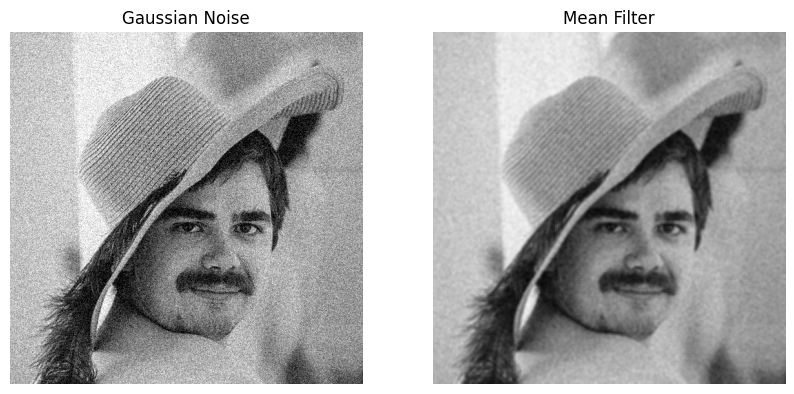

In [17]:
mean_filtered = cv2.blur(gaussian_noisy, ksize=(5,5))

show_images(
    [gaussian_noisy, mean_filtered],
    ["Gaussian Noise", "Mean Filter"]
)

### 2.2 Median Filter

Apply a median filter with kernel size `5` to the salt and pepper noisy image.

Display the noisy and filtered images side by side.

**Hint:** Use `cv2.medianBlur`.

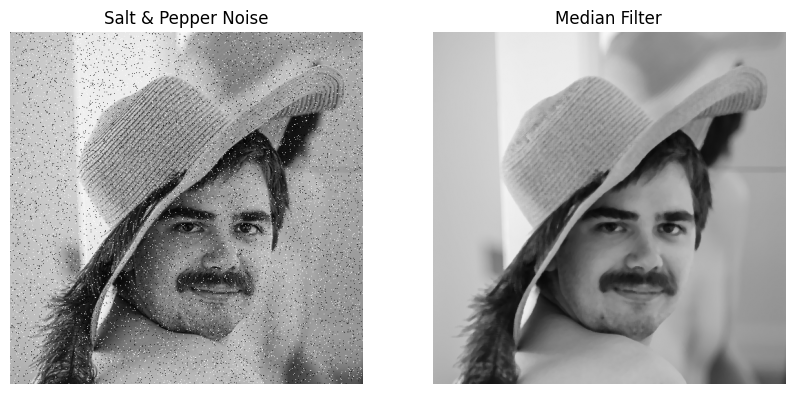

In [18]:
median_filtered = cv2.medianBlur(sp_noisy, ksize=5)

show_images(
    [sp_noisy, median_filtered],
    ["Salt & Pepper Noise", "Median Filter"]
)

### 2.3 Bilateral Filter

Apply a bilateral filter using:
- diameter = 9  
- sigmaColor = 75  
- sigmaSpace = 75  

Display the noisy and filtered images side by side.

(Optional) Play with the parameters, see if you can more appropriate better parameter values.

**Hint:** Use `cv2.bilateralFilter`.

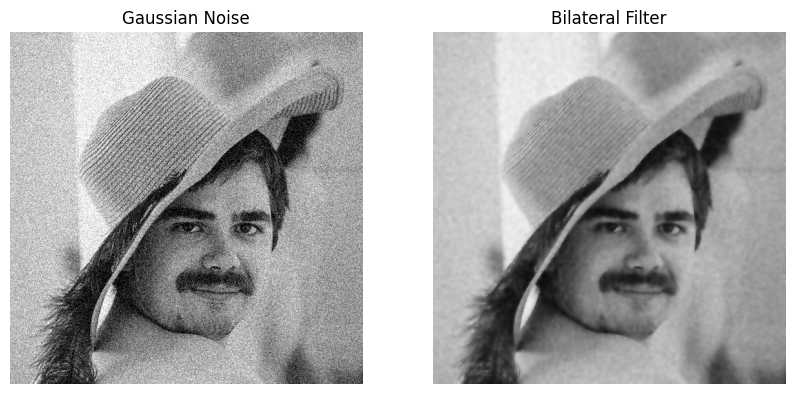

In [20]:
bilateral_filtered = cv2.bilateralFilter(gaussian_noisy.astype(np.float32), d=9, sigmaColor=75, sigmaSpace=75)

show_images(
    [gaussian_noisy, bilateral_filtered],
    ["Gaussian Noise", "Bilateral Filter"]
)

## 3. Histogram-Based Enhancement

Here is a helper function to create an image with a distorted intesity distribution.

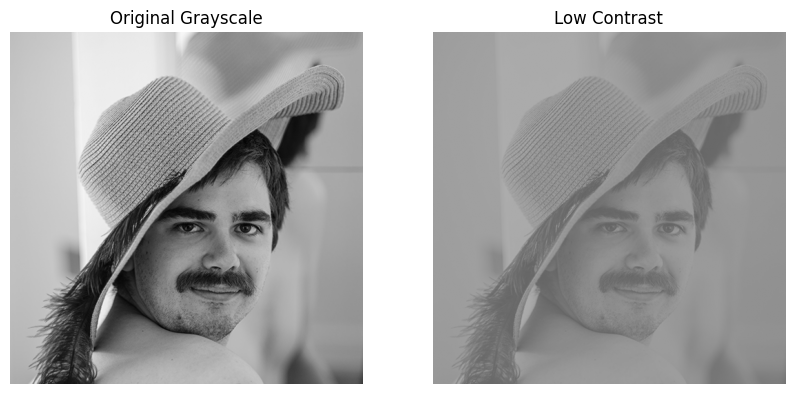

In [21]:
low_contrast = (0.3 * gray + 100).astype(np.uint8)
show_images(
    [gray, low_contrast],
    ["Original Grayscale", "Low Contrast"],
    cmap='gray'
)

### 3.1 Visualize Histograms

Plot the intensity histograms of the original grayscale image and the low-contrast image.

**Hint:** Use `plt.hist()` with 256 bins and range `[0, 256]`.

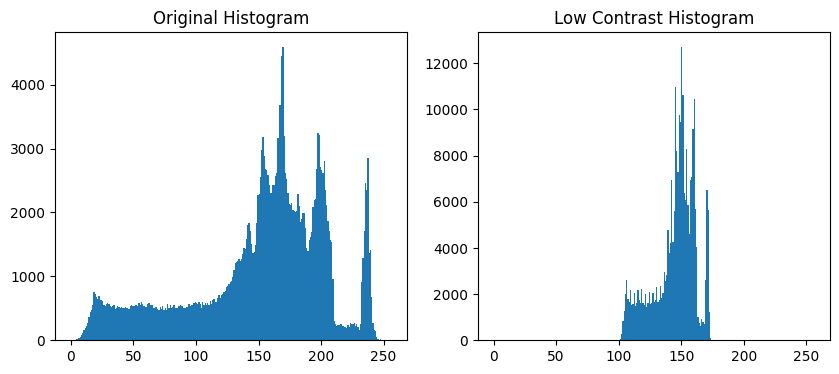

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(gray.flatten(), bins=256, range=(0,256))
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(low_contrast.flatten(), bins=256, range=(0,256))
plt.title("Low Contrast Histogram")

plt.show()


### 4.2 Contrast Stretching

Apply contrast stretching to the low-contrast image to restore the full intensity range `[0, 255]`.

Display the low-contrast, stretched image and their histograms side by side.

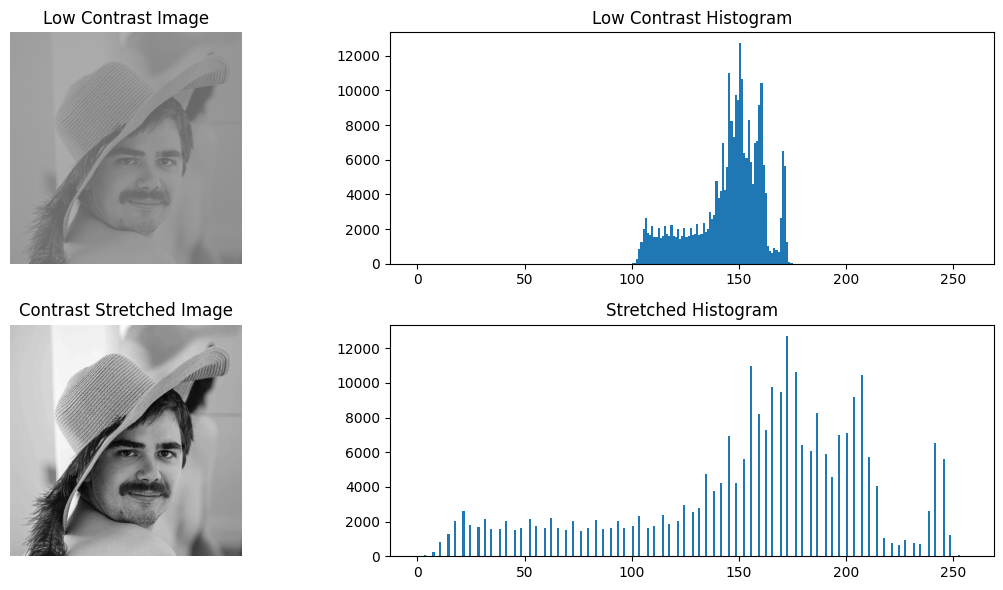

In [26]:
def contrast_stretch(image):
    max = np.max(image.flatten())
    min = np.min(image.flatten())
    copy = np.round((image-min)/(max-min)*255)
    return copy

stretched = contrast_stretch(low_contrast)

plt.figure(figsize=(12,6))

# Low contrast image
plt.subplot(2,2,1)
plt.imshow(low_contrast, cmap='gray', vmin=0, vmax=255)
plt.title("Low Contrast Image")
plt.axis('off')

# Low contrast histogram
plt.subplot(2,2,2)
plt.hist(low_contrast.flatten(), bins=256, range=(0,256))
plt.title("Low Contrast Histogram")

# Stretched image
plt.subplot(2,2,3)
plt.imshow(stretched, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast Stretched Image")
plt.axis('off')

# Stretched histogram
plt.subplot(2,2,4)
plt.hist(stretched.flatten(), bins=256, range=(0,256))
plt.title("Stretched Histogram")

plt.tight_layout()
plt.show()

### 3.3 Histogram Equalization
Apply histogram equalization using OpenCV.

Display the original grayscale and equalized images side by side.

**Hint:** Use `cv2.equalizeHist`.

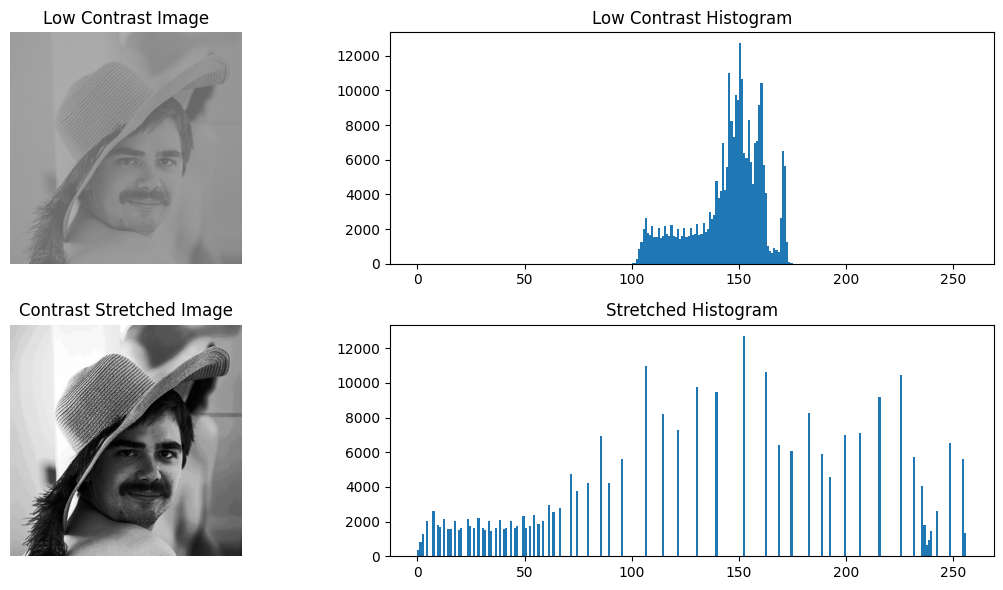

In [34]:
equalized = cv2.equalizeHist(low_contrast)

plt.figure(figsize=(12,6))

# Original grayscale
plt.subplot(2,2,1)
plt.imshow(low_contrast, cmap='gray', vmin=0, vmax=255)
plt.title("Low Contrast Image")
plt.axis('off')

# original histogram
plt.subplot(2,2,2)
plt.hist(low_contrast.flatten(), bins=256, range=(0,256))
plt.title("Low Contrast Histogram")

# Stretched image
plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast Stretched Image")
plt.axis('off')

# Stretched histogram
plt.subplot(2,2,4)
plt.hist(equalized.flatten(), bins=256, range=(0,256))
plt.title("Stretched Histogram")

plt.tight_layout()
plt.show()

### 3.4 CLAHE

Apply the CLAHE method on the low contrast image with:
- clipLimit = 6.0  
- tileGridSize = (8,8)  

Display the original grayscale and CLAHE result side by side.

**Hint:** Use `cv2.createCLAHE`.

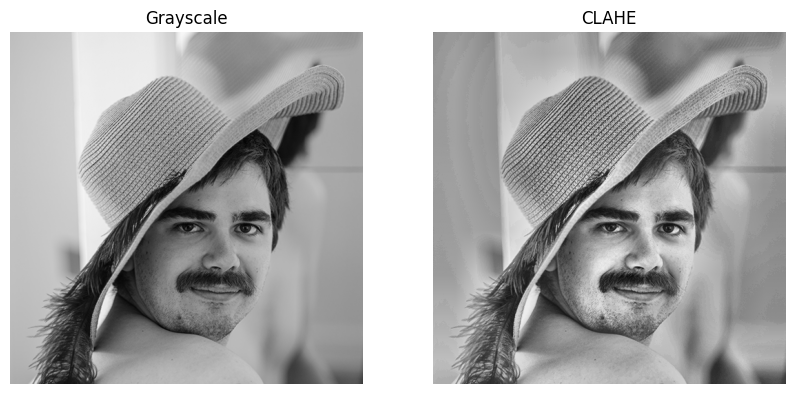

In [32]:

clahe = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8,8))
clahe_img = clahe.apply(low_contrast)
show_images(
    [gray, clahe_img],
    ["Grayscale", "CLAHE"],
    cmap='gray'
)

## 4. Inpainting (optional)
### Create Mask and Damaged Image



Create a rectangular mask and apply it to the grayscale image.

Display the original image, damaged image, and mask side by side.

In [ ]:
mask = ...

damaged = ...

show_images(
    [gray, damaged, mask],
    ["Original", "Damaged", "Mask"],
    cmap='gray'
)

### Apply Inpainting

Apply inpainting using:
- radius = 3  
- method = Telea  

Display the damaged and inpainted images side by side.

**Hint:** Use `cv2.inpaint`.

In [ ]:
inpainted = ...

show_images(
    [damaged, inpainted, inpainted2],
    ["Damaged", "Inpainted",""],
    cmap='gray'
)